# Multimodal Data Analysis and Matching
-  **Project Overview:**  
    - This notebook demonstrates a complete workflow for multimodal data analysis. We extract and process features from:
        - **Video Data:** A series of simulations with a ball following projectile motion in a 2D frame. We detect collisions with        frame boundaries.
         - **Audio Data:** Audio tracks associated with the videos where percussive onsets are used as features.

    - The two sets of features are then compared using the Jaccard similarity metric.
    - To guarantee a unique pairing, the Hungarian algorithm is used to maximize total similarity. 
    - Finally, we combine the matched audio and video files and save the final MP3 (extracted from the combined clip) in a separate folder.**

---




## Section 1. Setup and Imports
- First, we import all necessary libraries. These include OpenCV for video processing, Librosa for audio analysis, SciPy for signal processing and optimization, Matplotlib and Seaborn for visualization, and MoviePy for combining media files.
-  **Tip:** Ensure all dependencies are installed (e.g., via `pip install opencv-python-headless librosa moviepy seaborn scikit-learn`).
 



In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import find_peaks, peak_widths
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import jaccard_score
import librosa

# from moviepy.editor import VideoFileClip, AudioFileClip

# Create directories if they do not exist
if not os.path.exists('results'):
    os.makedirs('results')

# Set matplotlib style for consistency
plt.style.use('seaborn-whitegrid')


C:\Users\iitia\AppData\Local\Temp\ipykernel_15312\2488317908.py:19: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


## Section 2. Video Feature Extraction
- In this section, we process each video file to extract a binary collision state vector. The approach is as follows:
    1. **Video Reading:** Open each video file using OpenCV.  
    2. **Blob Detection:** Detect the moving ball using a blob detector (with constraints on area and circularity).  
    3. **Collision Detection:** Compute the extreme boundaries from the ball’s trajectory and mark time stamps where the ball is near a boundary.  
    4. **Interpolation:** Convert the collision events into a uniformly sampled binary vector (1 indicates a collision).
 
- We store all 45 feature vectors (one per video) in an array.
 

In [6]:


def extract_video_features(video_path, sample_rate=100, collision_thresh=2):
    """
    Process a video file to extract a uniform binary collision state vector.
    
    Parameters:
        video_path (str): Path to the video file.
        sample_rate (int): Sampling rate (Hz) to interpolate collision events.
        collision_thresh (int): Pixel threshold to consider a collision.
        
    Returns:
        collision_state (np.array): Uniform binary vector (1 for collision, 0 for no collision).
    """
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Configure blob detector to pick up the ball
    params = cv2.SimpleBlobDetector_Params()
    params.filterByArea = True
    params.minArea = 20
    params.maxArea = 500
    params.filterByCircularity = True
    params.minCircularity = 0.8
    detector = cv2.SimpleBlobDetector_create(params)
    
    time_points, x_coords, y_coords = [], [], []
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        keypoints = detector.detect(gray_frame)
        
        if keypoints:
            # Assume one ball per frame; process all detected keypoints (if multiple)
            for kp in keypoints:
                x, y = int(kp.pt[0]), int(kp.pt[1])
                frame_number = cap.get(cv2.CAP_PROP_POS_FRAMES)
                time_points.append(frame_number / fps)
                x_coords.append(x)
                y_coords.append(y)
                
    cap.release()
    cv2.destroyAllWindows()
    
    # Check if any data was collected
    if not x_coords or not y_coords:
        raise ValueError("No ball data was detected in " + video_path)
    
    # Compute boundaries from the detected ball positions
    left_boundary = min(x_coords)
    right_boundary = max(x_coords)
    top_boundary = min(y_coords)
    bottom_boundary = max(y_coords)
    
    # Create uniformly sampled time vector
    total_duration = time_points[-1]
    num_samples = int(total_duration * sample_rate)
    t_uniform = np.linspace(0, total_duration, num=num_samples)
    
    # Interpolate the x and y coordinates
    x_uniform = np.interp(t_uniform, time_points, x_coords)
    y_uniform = np.interp(t_uniform, time_points, y_coords)
    
    # Create a binary collision vector:
    # Mark 1 if the ball is near any boundary (left, right, or bottom in this case)
    collision_state = (
        (np.abs(x_uniform - left_boundary) < collision_thresh) |
        (np.abs(x_uniform - right_boundary) < collision_thresh) |
        (np.abs(y_uniform - bottom_boundary) < collision_thresh)
    ).astype(int)
    
    return collision_state

# Process all video files and store their features
video_folder = 'dataset/video_only'
num_videos = 45
video_features = []

for idx in range(1, num_videos + 1):
    video_file = os.path.join(video_folder, f'video_only_ID_{idx}.mp4')
    print(f"Processing video file: {video_file}")
    features = extract_video_features(video_file)
    video_features.append(features)

# Convert list of feature arrays into a 2D numpy array (padding shorter arrays if needed)
max_length = max(arr.shape[0] for arr in video_features)
padded_video_features = [np.pad(arr, (0, max_length - arr.shape[0]), mode='constant') 
                           for arr in video_features]
video_features = np.vstack(padded_video_features)

# For inspection, print the shape of the resulting feature matrix
print("Video feature matrix shape:", video_features.shape)


Processing video file: dataset/video_only\video_only_ID_1.mp4
Processing video file: dataset/video_only\video_only_ID_2.mp4
Processing video file: dataset/video_only\video_only_ID_3.mp4
Processing video file: dataset/video_only\video_only_ID_4.mp4
Processing video file: dataset/video_only\video_only_ID_5.mp4
Processing video file: dataset/video_only\video_only_ID_6.mp4
Processing video file: dataset/video_only\video_only_ID_7.mp4
Processing video file: dataset/video_only\video_only_ID_8.mp4
Processing video file: dataset/video_only\video_only_ID_9.mp4
Processing video file: dataset/video_only\video_only_ID_10.mp4
Processing video file: dataset/video_only\video_only_ID_11.mp4
Processing video file: dataset/video_only\video_only_ID_12.mp4
Processing video file: dataset/video_only\video_only_ID_13.mp4
Processing video file: dataset/video_only\video_only_ID_14.mp4
Processing video file: dataset/video_only\video_only_ID_15.mp4
Processing video file: dataset/video_only\video_only_ID_16.mp4
P

### Visualizing Video Features
- Let's plot a few of the collision state vectors extracted from the videos. Each row corresponds to one simulation.


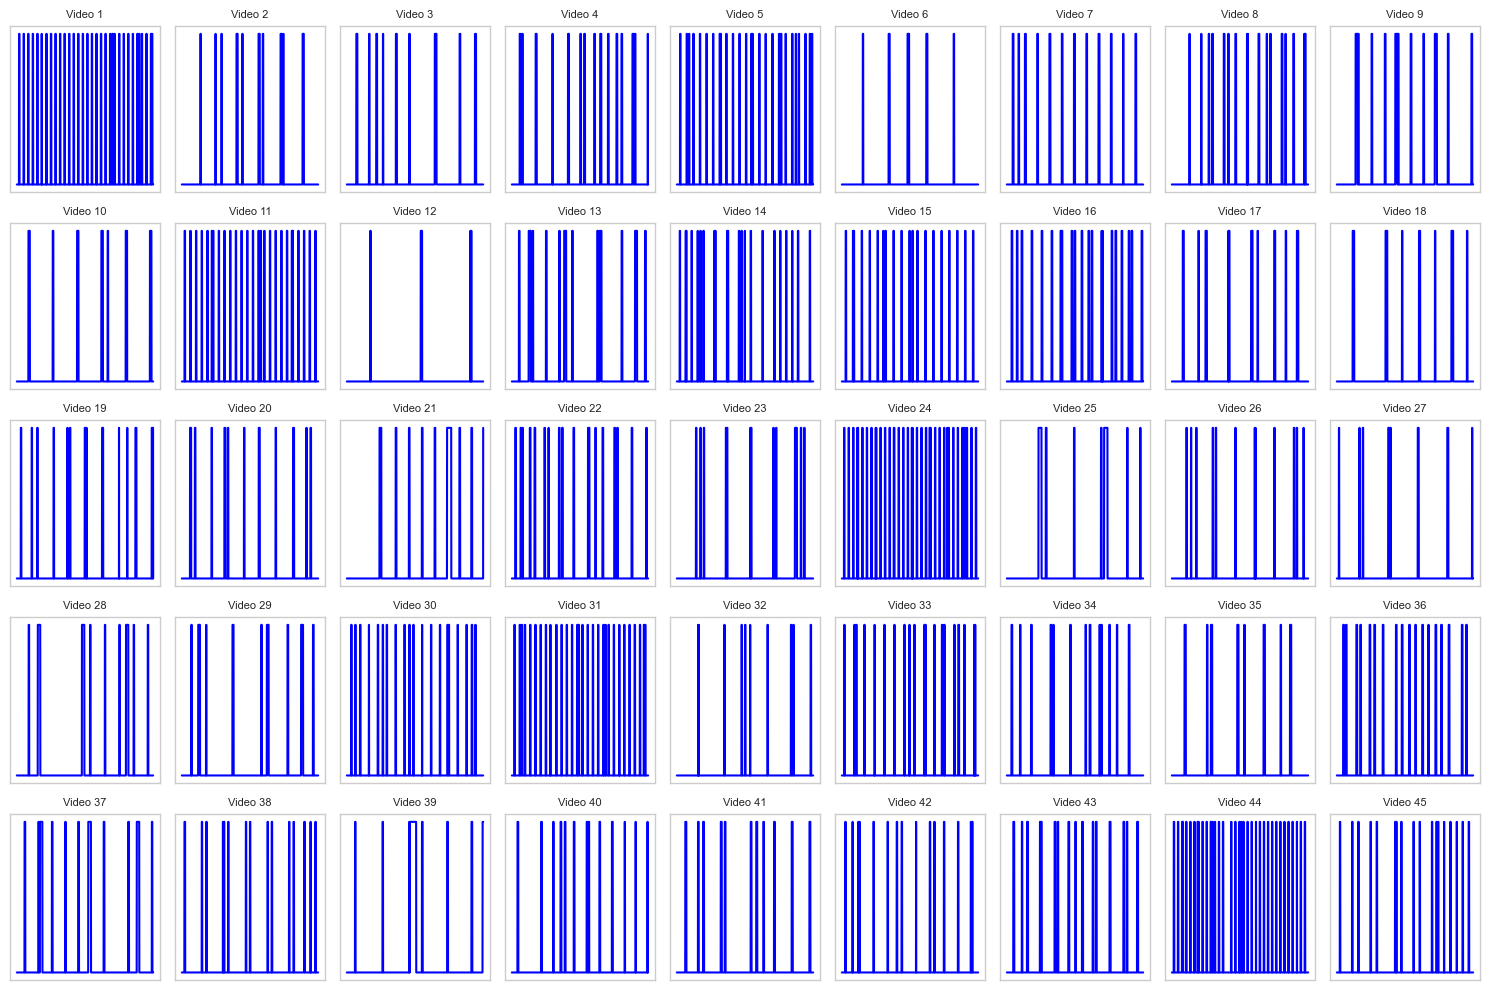

In [7]:


plt.figure(figsize=(15, 10))
rows, cols = 5, 9  # To display 45 plots in a grid

for i in range(video_features.shape[0]):
    plt.subplot(rows, cols, i + 1)
    plt.plot(video_features[i], color='blue')
    plt.title(f'Video {i+1}', fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


## Section 3. Audio Feature Extraction
- We now process each audio file. The extraction procedure is:
    1. **Load Audio:** Read the audio file using Librosa.  
    2. **Onset Envelope:** Compute the onset strength to highlight percussive events.  
    3. **Peak Detection:** Use SciPy's `find_peaks` and `peak_widths` to identify time intervals around each peak.  
    4. **Binary Vector:** Mark regions around the detected peaks as 1 and the rest as 0.



In [9]:

def extract_audio_features(audio_path, num_samples=2000, duration=20):
    """
    Extract a binary feature vector from an audio file by detecting onset peaks.
    
    Parameters:
        audio_path (str): Path to the audio file.
        num_samples (int): Length of the output binary vector.
        duration (float): Duration (in seconds) assumed for the audio file.
    
    Returns:
        binary_vector (np.array): A binary vector (1 indicating onset peak region).
    """
    # Load audio (using original sampling rate)
    y, sr = librosa.load(audio_path, sr=None)
    
    # Compute onset envelope (energy profile)
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    
    # Detect peaks in the onset envelope (threshold can be adjusted)
    peaks, _ = find_peaks(onset_env, height=0.2)
    widths, _, left_ips, right_ips = peak_widths(onset_env, peaks, rel_height=0.5)
    
    # Initialize the binary feature vector
    binary_vector = np.zeros(num_samples)
    
    # Map the detected peak intervals to the binary vector indices
    for i in range(len(peaks)):
        left_time = librosa.frames_to_time(left_ips[i], sr=sr)
        right_time = librosa.frames_to_time(right_ips[i], sr=sr)
        left_index = int((left_time / duration) * num_samples)
        right_index = int((right_time / duration) * num_samples)
        left_index = max(0, left_index)
        right_index = min(num_samples - 1, right_index)
        binary_vector[left_index:right_index+1] = 1
        
    return binary_vector

# Process all audio files and store their features
audio_folder = 'dataset/audio_only'
num_audio = 45
audio_features = []

for idx in range(1, num_audio + 1):
    audio_file = os.path.join(audio_folder, f'audio_only_ID_{idx}.wav')
    print(f"Processing audio file: {audio_file}")
    feat = extract_audio_features(audio_file)
    audio_features.append(feat)
    
# Convert list to a 2D numpy array
audio_features = np.vstack(audio_features)
print("Audio feature matrix shape:", audio_features.shape)


Processing audio file: dataset/audio_only\audio_only_ID_1.wav
Processing audio file: dataset/audio_only\audio_only_ID_2.wav
Processing audio file: dataset/audio_only\audio_only_ID_3.wav
Processing audio file: dataset/audio_only\audio_only_ID_4.wav
Processing audio file: dataset/audio_only\audio_only_ID_5.wav
Processing audio file: dataset/audio_only\audio_only_ID_6.wav
Processing audio file: dataset/audio_only\audio_only_ID_7.wav
Processing audio file: dataset/audio_only\audio_only_ID_8.wav
Processing audio file: dataset/audio_only\audio_only_ID_9.wav
Processing audio file: dataset/audio_only\audio_only_ID_10.wav
Processing audio file: dataset/audio_only\audio_only_ID_11.wav
Processing audio file: dataset/audio_only\audio_only_ID_12.wav
Processing audio file: dataset/audio_only\audio_only_ID_13.wav
Processing audio file: dataset/audio_only\audio_only_ID_14.wav
Processing audio file: dataset/audio_only\audio_only_ID_15.wav
Processing audio file: dataset/audio_only\audio_only_ID_16.wav
P

### Visualizing Audio Features
- Similar to the video features, we plot the binary vectors extracted from the audio files.


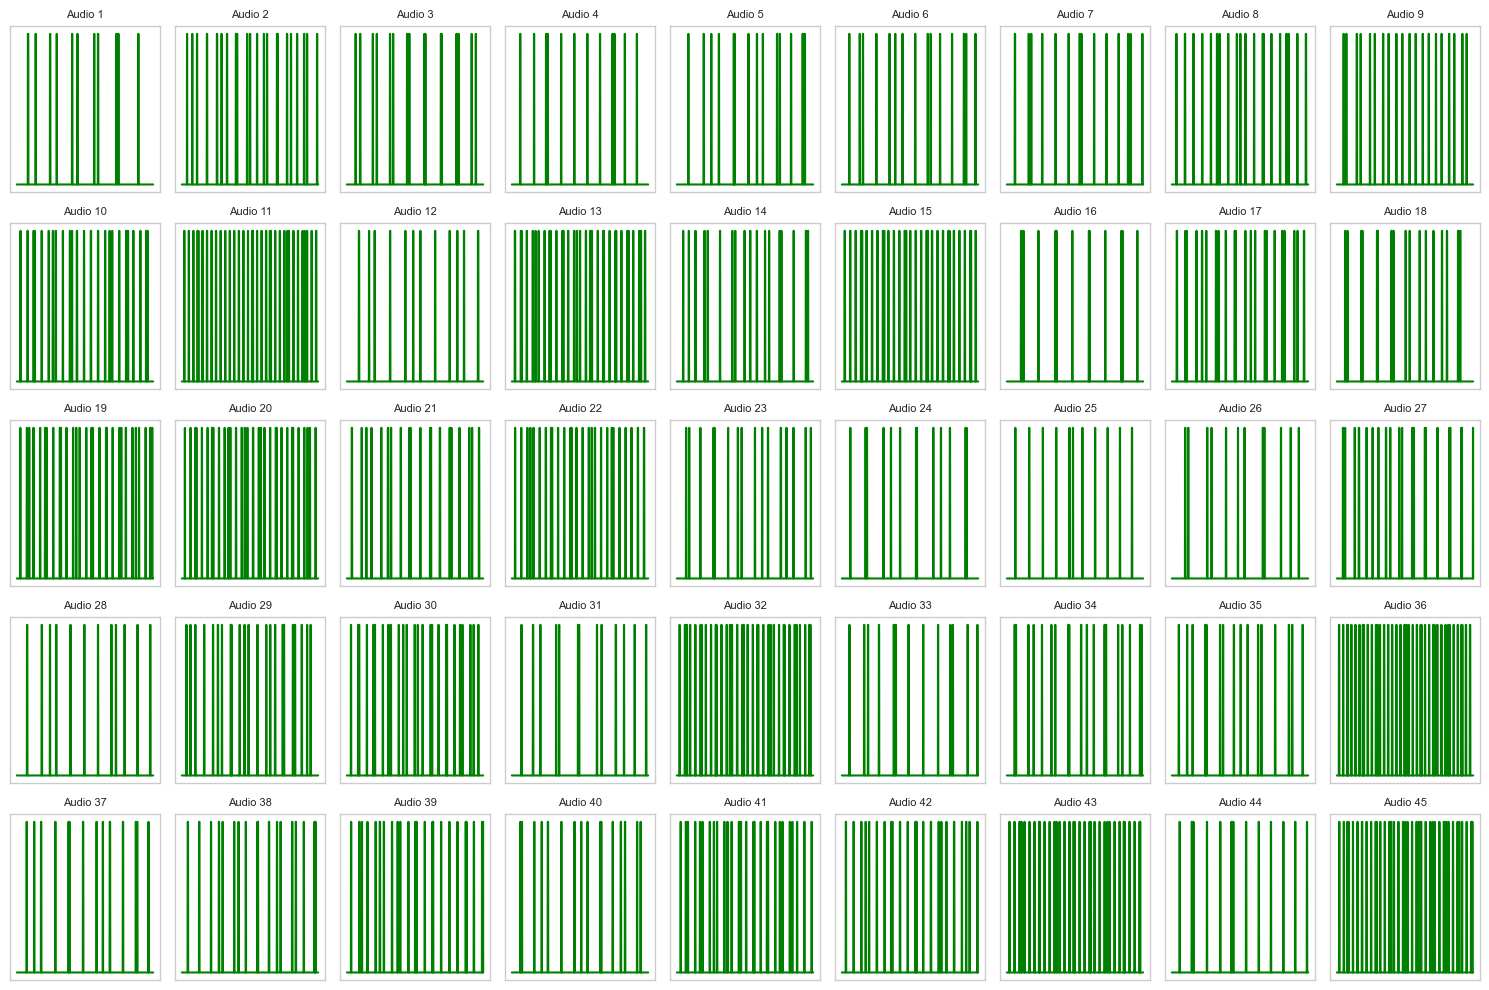

In [10]:


plt.figure(figsize=(15, 10))
rows, cols = 5, 9  # 45 plots in a grid

for i in range(audio_features.shape[0]):
    plt.subplot(rows, cols, i + 1)
    plt.plot(audio_features[i], color='green')
    plt.title(f'Audio {i+1}', fontsize=8)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


## Section 4. Matching Using Jaccard Similarity and the Hungarian Algorithm
- Here we compute a similarity matrix between each video and audio feature vector using the Jaccard index. The Jaccard similarity for binary vectors is defined as:
 \[
 \text{Jaccard}(A,B) = \frac{|A \cap B|}{|A \cup B|}
 \]
 
- We then apply the Hungarian algorithm to obtain a one-to-one assignment that maximizes total similarity.
 


Optimal Matching Results:
Video 1 matches Audio 45 with Jaccard Similarity: 0.4806
Video 2 matches Audio 1 with Jaccard Similarity: 0.3852
Video 3 matches Audio 40 with Jaccard Similarity: 0.3292
Video 4 matches Audio 18 with Jaccard Similarity: 0.3618
Video 5 matches Audio 19 with Jaccard Similarity: 0.5356
Video 6 matches Audio 31 with Jaccard Similarity: 0.2564
Video 7 matches Audio 14 with Jaccard Similarity: 0.3533
Video 8 matches Audio 38 with Jaccard Similarity: 0.3729
Video 9 matches Audio 44 with Jaccard Similarity: 0.3046
Video 10 matches Audio 23 with Jaccard Similarity: 0.1793
Video 11 matches Audio 20 with Jaccard Similarity: 0.4981
Video 12 matches Audio 24 with Jaccard Similarity: 0.2022
Video 13 matches Audio 6 with Jaccard Similarity: 0.3045
Video 14 matches Audio 13 with Jaccard Similarity: 0.3644
Video 15 matches Audio 30 with Jaccard Similarity: 0.4657
Video 16 matches Audio 2 with Jaccard Similarity: 0.4632
Video 17 matches Audio 5 with Jaccard Similarity: 0.2866
V

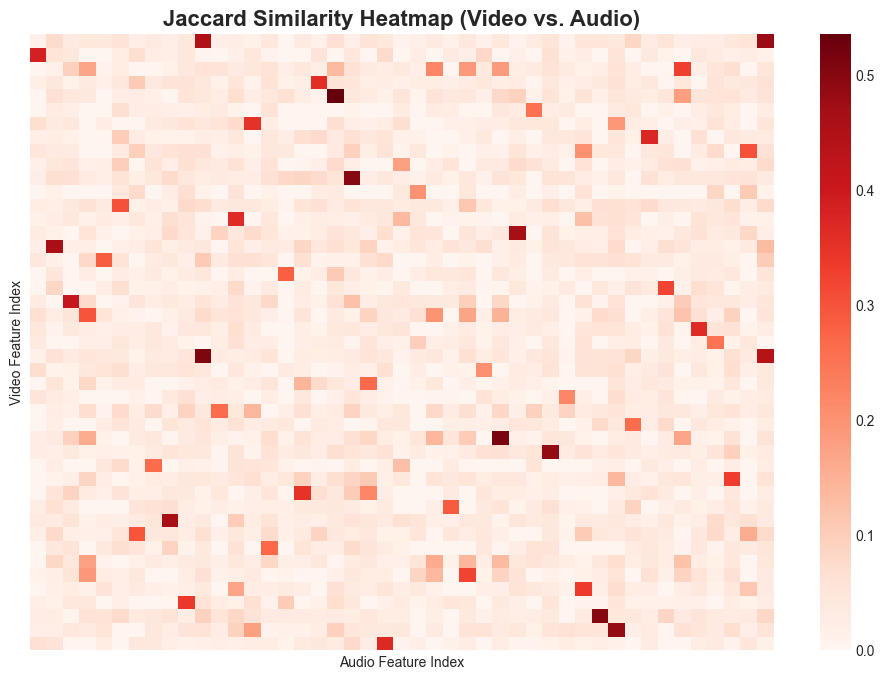

In [11]:

# Initialize the similarity matrix
num_items = video_features.shape[0]
similarity_matrix = np.zeros((num_items, num_items))

# Compute Jaccard similarity for each video-audio pair
for i in range(num_items):
    for j in range(num_items):
        similarity_matrix[i, j] = jaccard_score(video_features[i], audio_features[j])

# Use the Hungarian algorithm to maximize similarity.
# Since the algorithm minimizes cost by default, we pass the negative similarity matrix.
row_ind, col_ind = linear_sum_assignment(-similarity_matrix)

# Display the matching results
print("Optimal Matching Results:")
for i, j in zip(row_ind, col_ind):
    print(f"Video {i+1} matches Audio {j+1} with Jaccard Similarity: {similarity_matrix[i, j]:.4f}")

# Save the matching pairs in a CSV file
import pandas as pd
match_df = pd.DataFrame({'Video_ID': row_ind + 1, 'Audio_ID': col_ind + 1,
                         'Jaccard_Similarity': similarity_matrix[row_ind, col_ind]})
match_df.to_csv("matching_pairs.csv", index=False)
print("Matching pairs saved to 'matching_pairs.csv'.")

# Visualize the similarity matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(similarity_matrix, cmap='Reds', cbar=True, xticklabels=False, yticklabels=False)
plt.title('Jaccard Similarity Heatmap (Video vs. Audio)', fontsize=16, fontweight='bold')
plt.xlabel('Audio Feature Index')
plt.ylabel('Video Feature Index')
plt.show()


In [27]:
import pandas as pd



pairs = []
for video_idx, audio_idx in zip(row_ind, col_ind):
    # The +1 converts from 0-based index to the ID in the filename
    audio_filename = f"audio_only_ID_{audio_idx+1}.wav"
    video_filename = f"video_only_ID_{video_idx+1}.mp4"
    
    # Append the pair to a list
    pairs.append([audio_filename, video_filename])

# Convert to DataFrame with the desired columns
df = pd.DataFrame(pairs, columns=["AUDIO", "VIDEO"])

# Save to CSV
output_csv_path = "audio_video_mapping.csv"
df.to_csv(output_csv_path, index=False)

print(f"CSV file saved as: {output_csv_path}")


CSV file saved as: audio_video_mapping.csv


## Section 5. Combining Matched Audio and Video
- With the optimal pairing from the previous step, we now combine each video with its matching audio track. Using MoviePy, we:
    1. Load the silent video and the corresponding audio file.
    2. Attach the audio track to the video.
    3. Export the final combined clip.
    4. Extract and save the audio as an MP3 file into a dedicated "results" folder.
- This step serves as a final checkpoint to verify the matching quality.



In [23]:
import os
import subprocess

# Loop over each matched pair and combine the files.
for vid_idx, aud_idx in zip(row_ind, col_ind):
    video_path = os.path.join(video_folder, f'video_only_ID_{vid_idx+1}.mp4')
    audio_path = os.path.join(audio_folder, f'audio_only_ID_{aud_idx+1}.wav')
    
    print(f"Combining Video {vid_idx+1} and Audio {aud_idx+1}...")
    
    # Define output filename for the combined file
    combined_video_filename = os.path.join('results', f'combined_video_{vid_idx+1}_audio_{aud_idx+1}.mp4')
    
    # Update the ffmpeg_path to include the executable file
    ffmpeg_path = r"C:\Users\iitia\Downloads\ffmpeg-master-latest-win64-gpl-shared\ffmpeg-master-latest-win64-gpl-shared\bin\ffmpeg.exe"
    
    # FFmpeg command to combine video and audio without re-encoding video
    combine_cmd = [
        ffmpeg_path, "-y",         # Overwrite output file if it exists
        "-i", video_path,          # Input video file
        "-i", audio_path,          # Input audio file
        "-c:v", "copy",            # Copy video stream without re-encoding
        "-c:a", "aac",             # Encode audio as AAC
        combined_video_filename    # Output file
    ]

    try:
        subprocess.run(combine_cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        print(f"Combined file saved as: {combined_video_filename}")
    except subprocess.CalledProcessError as e:
        print(f"Error combining video and audio: {e.stderr.decode()}")
        continue

print("All matched files have been combined and saved in the 'results' folder.")


Combining Video 1 and Audio 45...
Combined file saved as: results\combined_video_1_audio_45.mp4
Combining Video 2 and Audio 1...
Combined file saved as: results\combined_video_2_audio_1.mp4
Combining Video 3 and Audio 40...
Combined file saved as: results\combined_video_3_audio_40.mp4
Combining Video 4 and Audio 18...
Combined file saved as: results\combined_video_4_audio_18.mp4
Combining Video 5 and Audio 19...
Combined file saved as: results\combined_video_5_audio_19.mp4
Combining Video 6 and Audio 31...
Combined file saved as: results\combined_video_6_audio_31.mp4
Combining Video 7 and Audio 14...
Combined file saved as: results\combined_video_7_audio_14.mp4
Combining Video 8 and Audio 38...
Combined file saved as: results\combined_video_8_audio_38.mp4
Combining Video 9 and Audio 44...
Combined file saved as: results\combined_video_9_audio_44.mp4
Combining Video 10 and Audio 23...
Combined file saved as: results\combined_video_10_audio_23.mp4
Combining Video 11 and Audio 20...
Combi

In [26]:
from IPython.display import Video, display
import os

# List of sample combined video filenames
sample_files = [f for f in os.listdir('results') if f.startswith('combined_video') and f.endswith('.mp4')]

# Display the first 3 combined video samples
for video_file in sample_files[:3]:
    video_path = os.path.join('results', video_file)
    print(f"Displaying: {video_file}")
    display(Video(video_path, embed=True, width=600))


Displaying: combined_video_10_audio_23.mp4


Displaying: combined_video_11_audio_20.mp4


Displaying: combined_video_12_audio_24.mp4


## Section 6. Additional Visualizations and Analysis
- Here we include a few more plots to explore the distribution of collision events and the spread of similarity values.



### 6.1 Collision Event Distribution (Sample Video)

- We plot the collision state over time for one example video to inspect the timing of collision events.


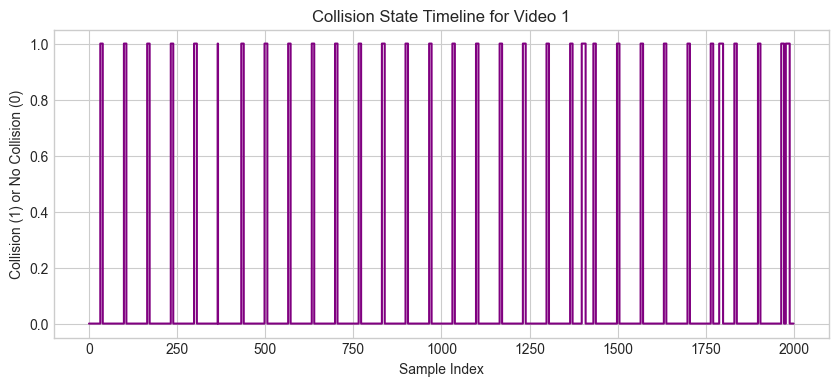

In [16]:

# Plot collision state for the first video feature vector
plt.figure(figsize=(10, 4))
plt.plot(video_features[0], drawstyle='steps-post', color='purple')
plt.title("Collision State Timeline for Video 1")
plt.xlabel("Sample Index")
plt.ylabel("Collision (1) or No Collision (0)")
plt.grid(True)
plt.show()




### 6.2 Similarity Value Distribution
- A histogram of the Jaccard similarity values (all pairwise values) can provide insights into how well the features align.


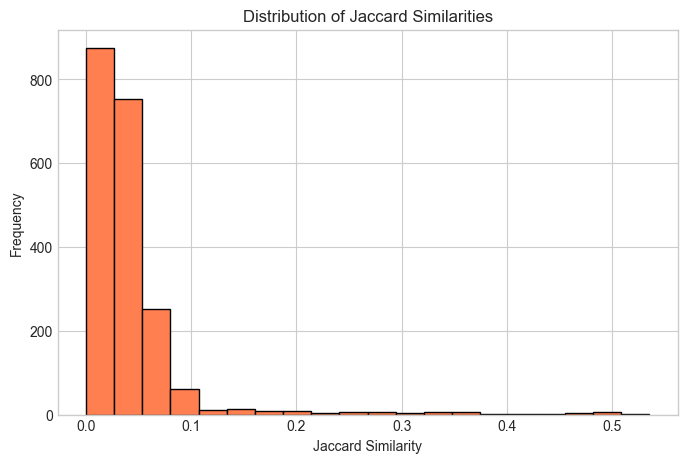

In [17]:

plt.figure(figsize=(8, 5))
plt.hist(similarity_matrix.flatten(), bins=20, color='coral', edgecolor='black')
plt.title("Distribution of Jaccard Similarities")
plt.xlabel("Jaccard Similarity")
plt.ylabel("Frequency")
plt.show()


## Conclusion
- In this notebook, we demonstrated:
    - **Feature Extraction:** How to derive binary collision vectors from video simulations and onset-based binary vectors from audio files.
    - **Matching Strategy:** The computation of a Jaccard similarity matrix and the use of the Hungarian algorithm for optimal one-to-one matching.
    - **Visualization:** Multiple plots to inspect feature dynamics and the similarity distribution.
    - **Media Combination:** How to combine the matched video and audio files, exporting the final audio as MP3 files.
- This workflow exemplifies a practical approach to multimodal data analysis, with clear documentation and visualization at each step.
---

